<a href="https://colab.research.google.com/github/Josezzz13/GRUPOKLW-ISB-2026-I/blob/main/Flexor_EMG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install opensignalsreader

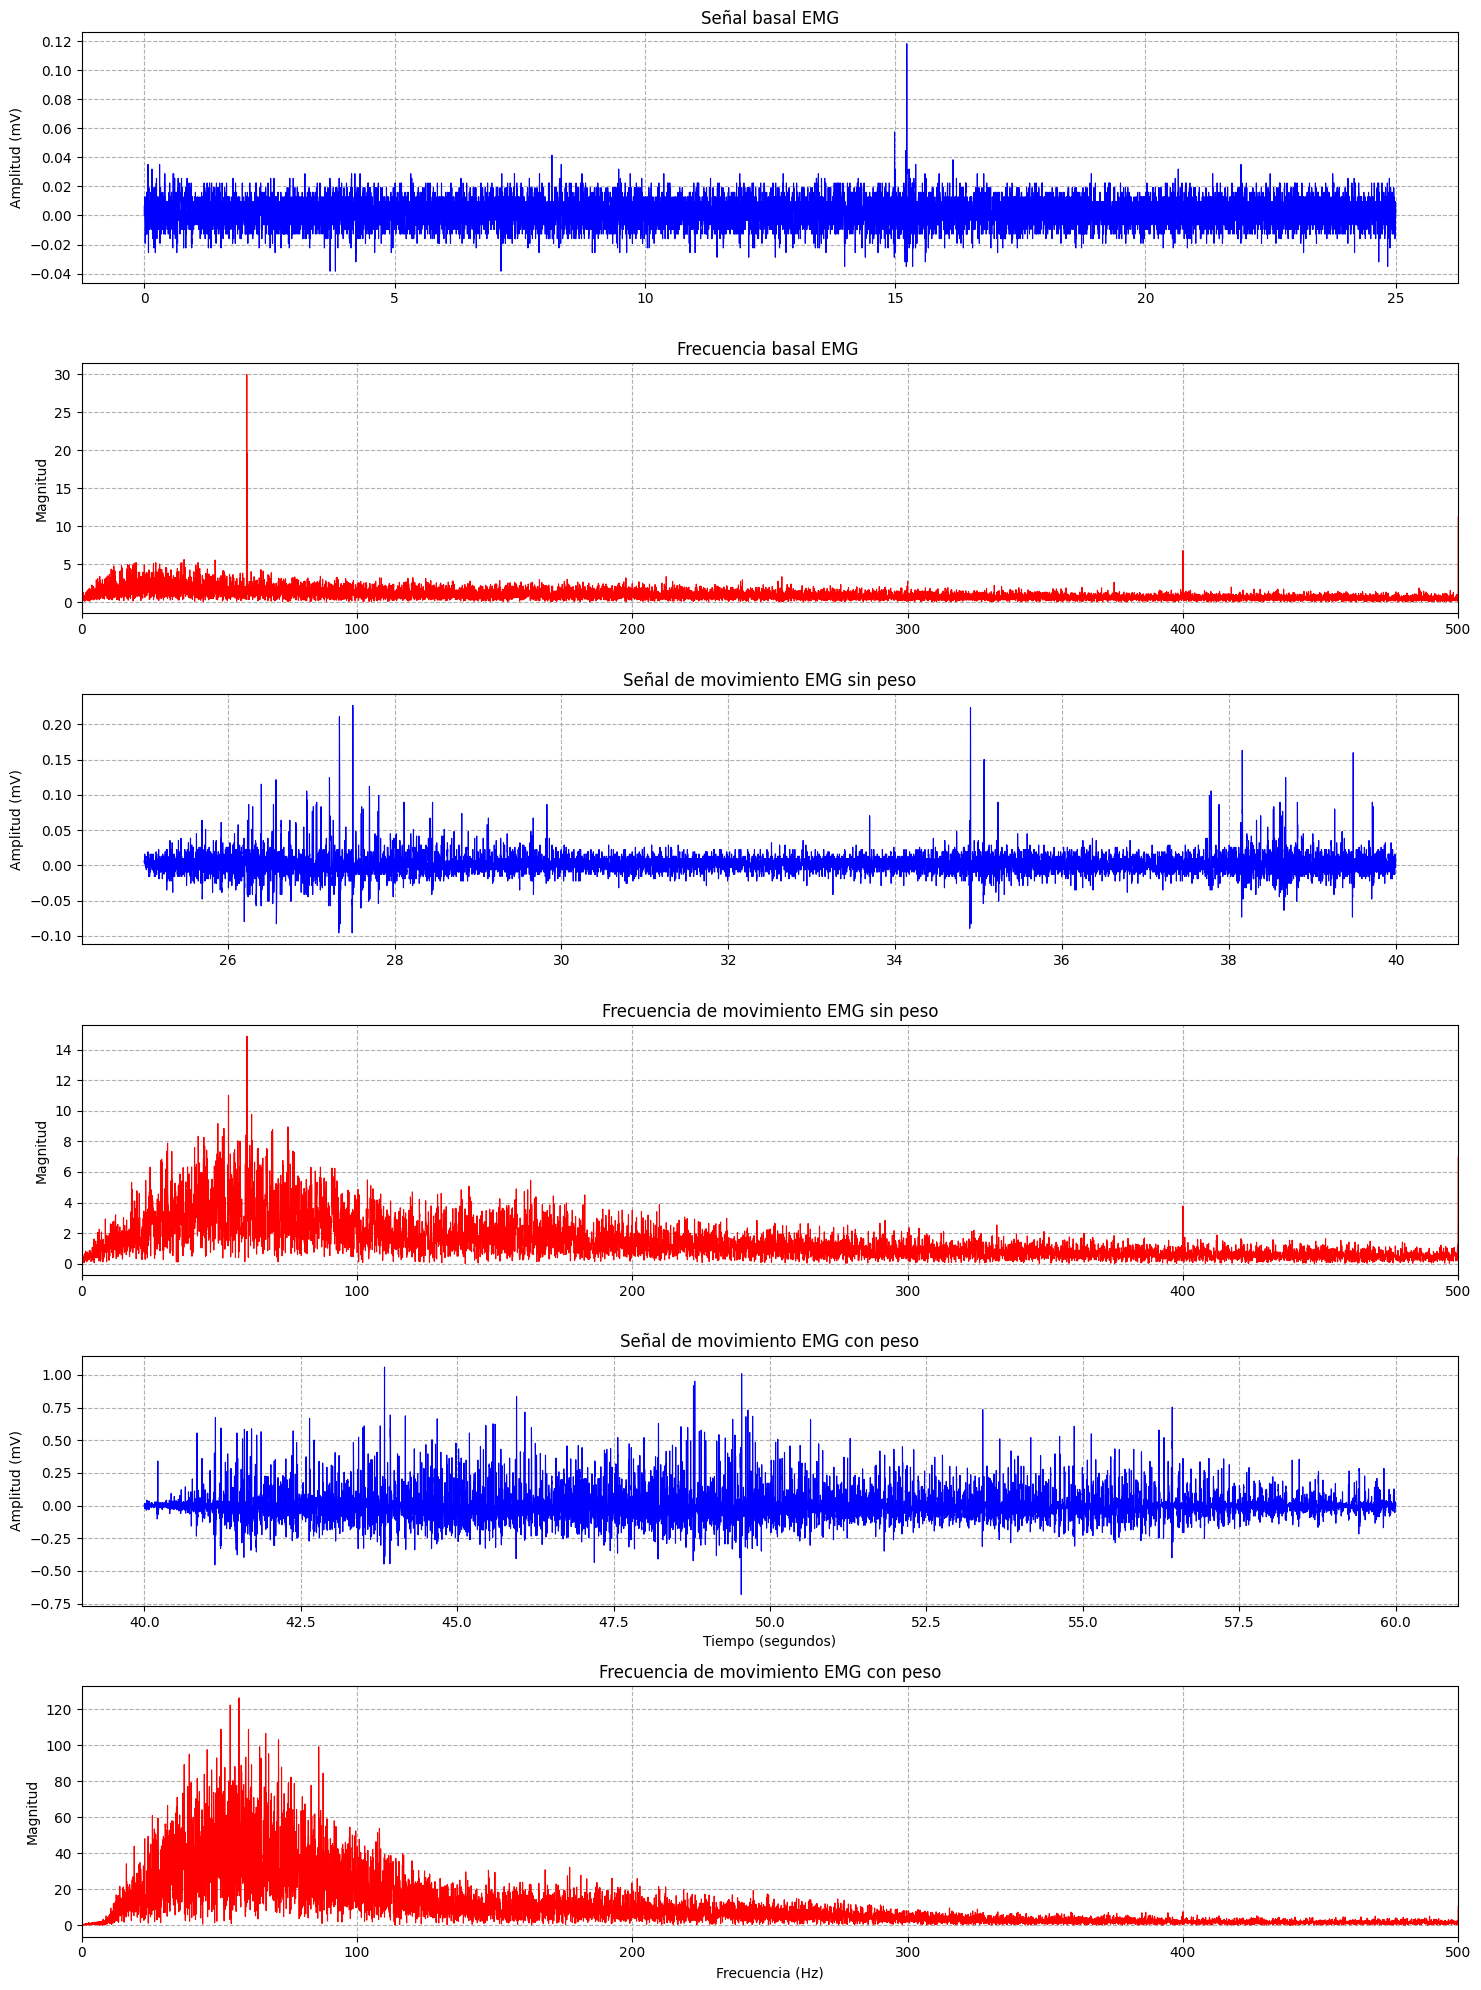

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from opensignalsreader import OpenSignalsReader

# Leemos el archivo que contiene la señal
nombre_archivo = 'Prueba3_Flexor.txt'
acq = OpenSignalsReader(nombre_archivo)

# Extraemos la señal EMG del canal 1
emg_signal = acq.signal(1)

# La frecuencia de muestreo establecida fue de 1000 Hz
fs = 1000.0

# Procesamamos la señal para el dominio del tiempo
N = len(emg_signal)
tiempo = np.arange(N) / fs

# --- Definimos los puntos de corte ---
idx_25 = int(25 * fs)   # Segundo 25
idx_40 = int(40 * fs)   # Segundo 40
idx_60 = int(60 * fs)   # Segundo 60

# --- Señales dividas ---
# Señal Basal
tiempo_basal = tiempo[:idx_25]
emg_basal = emg_signal[:idx_25]

# Movimiento sin peso
tiempo_mov_sin = tiempo[idx_25:idx_40]
emg_mov_sin = emg_signal[idx_25:idx_40]

# Movimiento con peso
tiempo_mov_con = tiempo[idx_40:idx_60]
emg_mov_con = emg_signal[idx_40:idx_60]


# Filtramos la componente de corriente continua (DC)
emg_basal_centrado = emg_basal - np.mean(emg_basal)
emg_mov_sin_centrado = emg_mov_sin - np.mean(emg_mov_sin)
emg_mov_con_centrado = emg_mov_con - np.mean(emg_mov_con)

# Procesamamos la señal para el dominio de la frecuencia
# (Transformada de Fourier)

# Espectro basal
freq_basal = np.fft.rfftfreq(len(emg_basal), d=1/fs)
esp_basal = np.abs(np.fft.rfft(emg_basal_centrado))

# Espectro movimiento sin peso
freq_mov_sin = np.fft.rfftfreq(len(emg_mov_sin), d=1/fs)
esp_mov_sin = np.abs(np.fft.rfft(emg_mov_sin_centrado))

# Espectro movimiento con peso
freq_mov_con = np.fft.rfftfreq(len(emg_mov_con), d=1/fs)
esp_mov_con = np.abs(np.fft.rfft(emg_mov_con_centrado))

# Creamos los subplots para la grafica
figure, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, figsize=(15, 20))

# --- Ploteamos la señales ---
# Ploteamos la señal basal EMG
ax1.plot(tiempo_basal, emg_basal, color='blue', linewidth=0.8)
ax1.set_title('Señal basal EMG')
ax1.set_ylabel('Amplitud (mV)')
ax1.grid(True, linestyle='--')

# Ploteamos la frecuencia basal EMG
ax2.plot(freq_basal, esp_basal, color='red', linewidth=0.8)
ax2.set_title('Frecuencia basal EMG ')
ax2.set_ylabel('Magnitud')
ax2.set_xlim(0, 500)
ax2.grid(True, linestyle='--')


# Ploteamos la señal de movimiento EMG sin peso
ax3.plot(tiempo_mov_sin, emg_mov_sin, color='blue', linewidth=0.8)
ax3.set_title('Señal de movimiento EMG sin peso')
ax3.set_ylabel('Amplitud (mV)')
ax3.grid(True, linestyle='--')

# Ploteamos la frecuencia de movimiento EMG sin peso
ax4.plot(freq_mov_sin, esp_mov_sin, color='red', linewidth=0.8)
ax4.set_title('Frecuencia de movimiento EMG sin peso')
ax4.set_ylabel('Magnitud')
ax4.set_xlim(0, 500)
ax4.grid(True, linestyle='--')

# Ploteamos la señal de movimiento EMG con peso
ax5.plot(tiempo_mov_con, emg_mov_con, color='blue', linewidth=0.8)
ax5.set_title('Señal de movimiento EMG con peso')
ax5.set_xlabel('Tiempo (segundos)')
ax5.set_ylabel('Amplitud (mV)')
ax5.grid(True, linestyle='--')

# Ploteamos la frecuencia de movimiento EMG con peso
ax6.plot(freq_mov_con, esp_mov_con, color='red', linewidth=0.8)
ax6.set_title('Frecuencia de movimiento EMG con peso')
ax6.set_xlabel('Frecuencia (Hz)')
ax6.set_ylabel('Magnitud')
ax6.set_xlim(0, 500)
ax6.grid(True, linestyle='--')


plt.tight_layout()
plt.show()